# 08 Ensemble - Centrality and Embeddings

Combine the centrality/classical approach and the embedding approach using saved predictions.

This notebook does not retrain the base models. It builds two ensemble predictions:

- **Median**: median of centrality prediction and embedding prediction.
- **Stack**: Ridge stacking model trained on validation predictions and evaluated on test predictions.

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
from src.models.ml_train_and_store import top1_bank_cohort, top1_metrics

PREDICTIONS_ROOT = PROJECT_ROOT / 'src' / 'data' / 'predictions'
OUT_DIR = PREDICTIONS_ROOT / '08_ensemble_centrality_embeddings'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'log_systemic_risk_label'
ROUND_DECIMALS = 3
P_ORDER = ['p0', 'p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40']
P_RANK = {p: i for i, p in enumerate(P_ORDER)}

CENTRALITY_PREDICTIONS_PATH = PREDICTIONS_ROOT / '04b_saved_04a' / 'predictions.csv'
EMBEDDING_PREDICTIONS_PATH = PREDICTIONS_ROOT / '05d_saved_05a' / 'predictions.csv'

REQUIRED_COLUMNS = [
    'dataset', 'experiment', 'model', 'split', 'bank_id', TARGET_COL, 'prediction'
]
MERGE_KEYS = ['dataset', 'split', 'bank_id', 'year', 'quarter', 'period']

pd.set_option('display.max_columns', 120)
print(PROJECT_ROOT)
print('Centrality predictions:', CENTRALITY_PREDICTIONS_PATH)
print('Embedding predictions:', EMBEDDING_PREDICTIONS_PATH)

/Users/rubenmarques/Documents/Repositórios/Thesis
Centrality predictions: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/04b_saved_04a/predictions.csv
Embedding predictions: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/05d_saved_05a/predictions.csv


## Load saved predictions

In [4]:
def load_predictions(path, approach):
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path)
    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f'{path.name} missing required columns: {missing}')

    keep_cols = [col for col in MERGE_KEYS if col in df.columns]
    keep_cols += [TARGET_COL, 'prediction', 'experiment', 'model']
    df = df[keep_cols].copy()
    df = df.rename(columns={
        TARGET_COL: f'{approach}_target',
        'prediction': f'{approach}_prediction',
        'experiment': f'{approach}_experiment',
        'model': f'{approach}_model',
    })
    return df


centrality = load_predictions(CENTRALITY_PREDICTIONS_PATH, 'centrality')
embeddings = load_predictions(EMBEDDING_PREDICTIONS_PATH, 'embedding')

merge_keys = [col for col in MERGE_KEYS if col in centrality.columns and col in embeddings.columns]

for name, df in [('centrality', centrality), ('embedding', embeddings)]:
    duplicates = df.duplicated(merge_keys).sum()
    if duplicates:
        raise ValueError(f'{name} predictions have {duplicates} duplicated merge keys')

combined = centrality.merge(embeddings, on=merge_keys, how='inner')
if len(combined) != len(centrality) or len(combined) != len(embeddings):
    raise ValueError(
        f'Prediction merge lost rows: centrality={len(centrality)}, '
        f'embedding={len(embeddings)}, merged={len(combined)}'
    )

target_diff = (combined['centrality_target'] - combined['embedding_target']).abs().max()
if target_diff > 1e-9:
    raise ValueError(f'Target mismatch between approaches. Max diff: {target_diff}')

combined[TARGET_COL] = combined['centrality_target']
combined = combined.drop(columns=['centrality_target', 'embedding_target'])
combined['dataset_group'] = combined['dataset'].str.extract(r'^(dataset[12])')[0]
combined['p'] = combined['dataset'].str.extract(r'_(p\d+)$')[0]
combined.loc[combined['dataset'].str.endswith('_baseline'), 'p'] = 'p0'
combined['p_num'] = combined['p'].map(P_RANK)
combined = combined.sort_values(['dataset_group', 'p_num', 'split', 'bank_id']).reset_index(drop=True)

print('Merged predictions:', combined.shape)
display(combined.head())

Merged predictions: (1294884, 16)


,dataset,split,bank_id,year,quarter,period,centrality_prediction,centrality_experiment,centrality_model,embedding_prediction,embedding_experiment,embedding_model,log_systemic_risk_label,dataset_group,p,p_num
0,dataset1_baseline,test,0,2023.0,1.0,2023Q1,3.348884,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),1.191369,dataset1_temporal_train_05a_specs,MLP (tuned),4.043051,dataset1,p0,0
1,dataset1_baseline,test,0,2023.0,2.0,2023Q2,3.937524,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),1.174829,dataset1_temporal_train_05a_specs,MLP (tuned),3.828641,dataset1,p0,0
2,dataset1_baseline,test,0,2023.0,3.0,2023Q3,3.944458,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),0.698572,dataset1_temporal_train_05a_specs,MLP (tuned),3.988984,dataset1,p0,0
3,dataset1_baseline,test,1,2023.0,1.0,2023Q1,2.395905,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),2.405118,dataset1_temporal_train_05a_specs,MLP (tuned),3.737670,dataset1,p0,0
4,dataset1_baseline,test,1,2023.0,2.0,2023Q2,3.313929,dataset1_temporal_train_04a_specs,Gradient Boosting (tuned),1.213817,dataset1_temporal_train_05a_specs,MLP (tuned),3.433987,dataset1,p0,0


## Ensemble helpers

In [5]:
def regression_metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'r2': r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan,
    }


def evaluate_predictions(df, pred_col, cohort):
    m = regression_metrics(df[TARGET_COL], df[pred_col])
    t = top1_metrics(df, df[pred_col].to_numpy(), cohort, TARGET_COL)
    return {
        'test_mae': m['mae'],
        'test_rmse': m['rmse'],
        'test_r2': m['r2'],
        'test_top1_mae': t['mae'],
        'test_top1_rmse': t['rmse'],
    }


def fit_stack_model(validation_df):
    x_val = validation_df[['centrality_prediction', 'embedding_prediction']]
    y_val = validation_df[TARGET_COL]
    stack_model = LinearRegression()
    stack_model.fit(x_val, y_val)
    return stack_model


def build_ensemble_for_dataset(dataset_df):
    dataset_name = dataset_df['dataset'].iloc[0]
    train_df = dataset_df[dataset_df['split'] == 'train'].copy()
    validation_df = dataset_df[dataset_df['split'] == 'validation'].copy()
    test_df = dataset_df[dataset_df['split'] == 'test'].copy()

    if validation_df.empty or test_df.empty:
        raise ValueError(f'Missing validation/test split for {dataset_name}')

    # Define the top-1% bank cohort from training rows only. Dataset 2 has 1 row per
    # bank with no cross-split overlap, so we skip top-1% there (cohort=empty -> NaN).
    if dataset_name.startswith('dataset2_'):
        cohort = set()
    else:
        cohort_source = train_df if not train_df.empty else validation_df
        cohort = top1_bank_cohort(cohort_source, TARGET_COL)

    stack_model = fit_stack_model(validation_df)

    test_df['median_prediction'] = test_df[['centrality_prediction', 'embedding_prediction']].median(axis=1)
    test_df['stack_prediction'] = stack_model.predict(
        test_df[['centrality_prediction', 'embedding_prediction']]
    )

    prediction_cols = {
        'Centrality': 'centrality_prediction',
        'Embeddings': 'embedding_prediction',
        'Median': 'median_prediction',
        'Stack': 'stack_prediction',
    }

    rows = []
    for method, pred_col in prediction_cols.items():
        row = {
            'dataset': dataset_name,
            'dataset_group': test_df['dataset_group'].iloc[0],
            'p': test_df['p'].iloc[0],
            'p_num': test_df['p_num'].iloc[0],
            'method': method,
            'stack_intercept': stack_model.intercept_ if method == 'Stack' else np.nan,
            'stack_coef_centrality': stack_model.coef_[0] if method == 'Stack' else np.nan,
            'stack_coef_embedding': stack_model.coef_[1] if method == 'Stack' else np.nan,
        }
        row.update(evaluate_predictions(test_df, pred_col, cohort))
        rows.append(row)

    pred_keep_cols = [col for col in merge_keys if col in test_df.columns]
    pred_keep_cols += [
        TARGET_COL,
        'dataset_group',
        'p',
        'p_num',
        'centrality_prediction',
        'embedding_prediction',
        'median_prediction',
        'stack_prediction',
        'centrality_experiment',
        'embedding_experiment',
        'centrality_model',
        'embedding_model',
    ]

    return rows, test_df[pred_keep_cols].copy()


## Build median and stacked ensembles

In [6]:
metric_rows = []
prediction_frames = []

for dataset_name, dataset_df in combined.groupby('dataset', sort=False):
    rows, preds = build_ensemble_for_dataset(dataset_df)
    metric_rows.extend(rows)
    prediction_frames.append(preds)

metrics = pd.DataFrame(metric_rows).sort_values(['dataset_group', 'p_num', 'method']).reset_index(drop=True)
ensemble_predictions = pd.concat(prediction_frames, ignore_index=True)

metric_cols = [col for col in metrics.columns if any(name in col for name in ['mae', 'rmse', 'r2', 'coef', 'intercept'])]
metrics[metric_cols] = metrics[metric_cols].round(ROUND_DECIMALS)

prediction_metric_cols = [
    'centrality_prediction', 'embedding_prediction', 'median_prediction', 'stack_prediction'
]
ensemble_predictions[prediction_metric_cols] = ensemble_predictions[prediction_metric_cols].round(ROUND_DECIMALS)

metrics_path = OUT_DIR / 'metrics.csv'
predictions_path = OUT_DIR / 'predictions.csv'
metrics.to_csv(metrics_path, index=False)
ensemble_predictions.to_csv(predictions_path, index=False)

print(f'Saved metrics: {metrics_path}')
print(f'Saved predictions: {predictions_path}')
display(metrics.head(20))

Saved metrics: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/08_ensemble_centrality_embeddings/metrics.csv
Saved predictions: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/08_ensemble_centrality_embeddings/predictions.csv


,dataset,dataset_group,p,p_num,method,stack_intercept,stack_coef_centrality,stack_coef_embedding,test_mae,test_rmse,test_r2,test_top1_mae,test_top1_rmse
0,dataset1_baseline,dataset1,p0,0,Centrality,NaN,NaN,NaN,0.012,0.070,0.880,0.366,0.451
1,dataset1_baseline,dataset1,p0,0,Embeddings,NaN,NaN,NaN,0.025,0.169,0.292,1.310,1.521
2,dataset1_baseline,dataset1,p0,0,Median,NaN,NaN,NaN,0.017,0.105,0.730,0.758,0.883
3,dataset1_baseline,dataset1,p0,0,Stack,-0.205,1.118,0.180,0.014,0.070,0.880,0.348,0.428
4,dataset1_p5,dataset1,p5,1,Centrality,NaN,NaN,NaN,0.012,0.069,0.889,0.351,0.431
5,dataset1_p5,dataset1,p5,1,Embeddings,NaN,NaN,NaN,0.036,0.169,0.338,1.276,1.485
6,dataset1_p5,dataset1,p5,1,Median,NaN,NaN,NaN,0.022,0.103,0.755,0.728,0.846
7,dataset1_p5,dataset1,p5,1,Stack,-0.168,1.156,0.089,0.014,0.073,0.878,0.362,0.444
8,dataset1_p10,dataset1,p10,2,Centrality,NaN,NaN,NaN,0.013,0.070,0.896,0.359,0.439
9,dataset1_p10,dataset1,p10,2,Embeddings,NaN,NaN,NaN,0.029,0.165,0.413,1.235,1.464


## Comparison plots

In [7]:
METHOD_COLORS = {
    'Centrality': '#2ca02c',
    'Embeddings': '#1f77b4',
    'Median': '#ff7f0e',
    'Stack': '#9467bd',
}

METRIC_PANELS = [
    ('test_rmse', 'Test RMSE'),
    ('test_mae', 'Test MAE'),
    ('test_top1_rmse', 'Top 1% test RMSE'),
    ('test_top1_mae', 'Top 1% test MAE'),
]


def plot_dataset_ensemble(metrics_df, dataset_group, output_filename):
    plot_df = metrics_df[metrics_df['dataset_group'] == dataset_group].copy()
    plot_df = plot_df.sort_values(['p_num', 'method'])

    panels = METRIC_PANELS if dataset_group == 'dataset1' else [p for p in METRIC_PANELS if 'top1' not in p[0]]
    nrows, ncols = (2, 2) if len(panels) == 4 else (1, 2)

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows), sharex=True)
    axes = axes.ravel()

    for ax, (metric_col, metric_title) in zip(axes, panels):
        for method in ['Centrality', 'Embeddings', 'Median', 'Stack']:
            group = plot_df[plot_df['method'] == method].sort_values('p_num')
            ax.plot(
                group['p'],
                group[metric_col],
                marker='o',
                linewidth=2,
                label=method,
                color=METHOD_COLORS[method],
            )
        ax.set_title(metric_title)
        ax.set_xlabel('p (default threshold)')
        ax.set_ylabel('Error')
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.suptitle(f'{dataset_group.title()} - Centrality + Embeddings ensembles', fontsize=14)
    fig.tight_layout()

    output_path = OUT_DIR / output_filename
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {output_path}')


def winner_table(metrics_df, dataset_group):
    table = metrics_df[metrics_df['dataset_group'] == dataset_group].copy()
    include_top1 = dataset_group == 'dataset1'
    winners = []
    for p, group in table.groupby('p', sort=False):
        best_rmse = group.loc[group['test_rmse'].idxmin()]
        row = {
            'p': p,
            'best_test_rmse_method': best_rmse['method'],
            'best_test_rmse': best_rmse['test_rmse'],
        }
        if include_top1:
            best_top1 = group.loc[group['test_top1_rmse'].idxmin()]
            row['best_top1_rmse_method'] = best_top1['method']
            row['best_top1_rmse'] = best_top1['test_top1_rmse']
        winners.append(row)
    return pd.DataFrame(winners).sort_values(
        'p', key=lambda s: s.map(P_RANK)
    ).reset_index(drop=True)


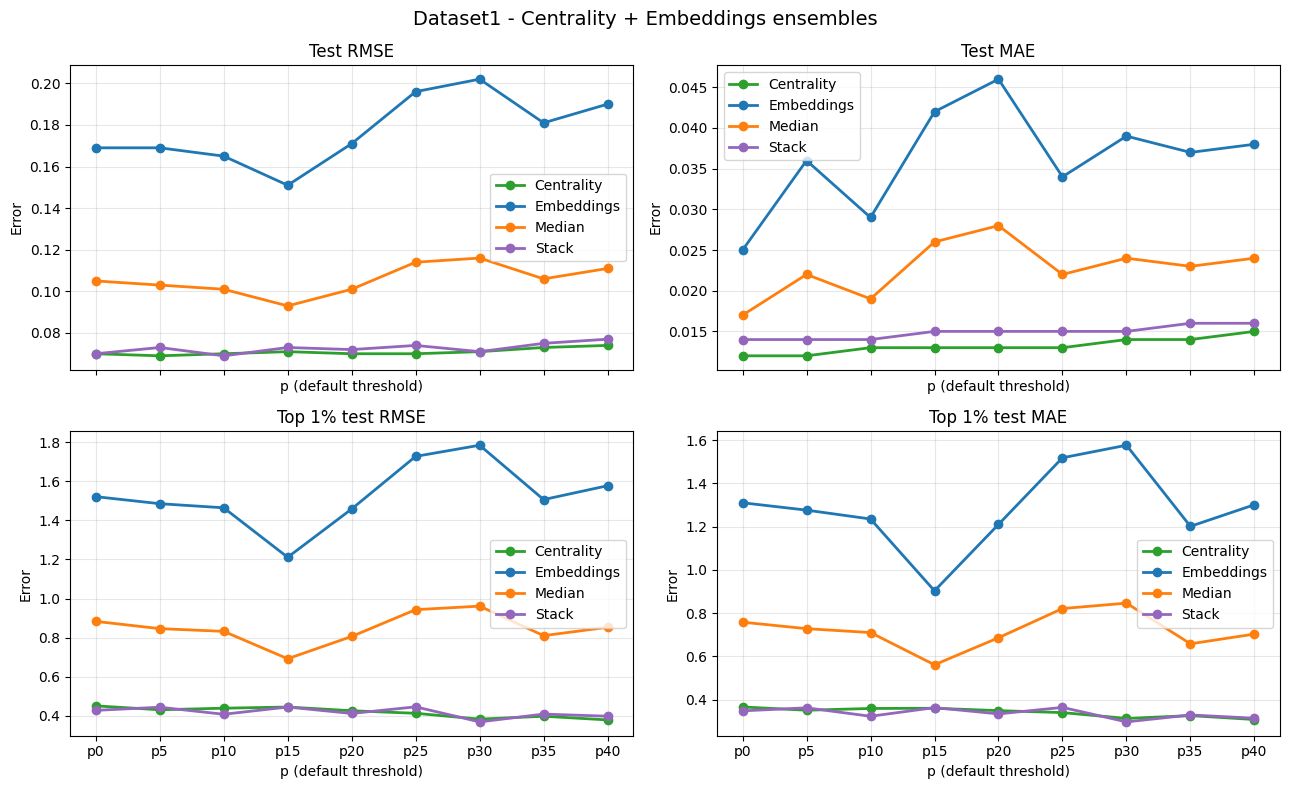

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/08_ensemble_centrality_embeddings/dataset1_ensemble_comparison.png


,p,best_test_rmse_method,best_test_rmse,best_top1_rmse_method,best_top1_rmse
0,p0,Centrality,0.070,Stack,0.428
1,p5,Centrality,0.069,Centrality,0.431
2,p10,Stack,0.069,Stack,0.408
3,p15,Centrality,0.071,Centrality,0.445
4,p20,Centrality,0.070,Stack,0.412
5,p25,Centrality,0.070,Centrality,0.413
6,p30,Centrality,0.071,Stack,0.369
7,p35,Centrality,0.073,Centrality,0.398
8,p40,Centrality,0.074,Centrality,0.379


In [8]:
plot_dataset_ensemble(metrics, 'dataset1', 'dataset1_ensemble_comparison.png')
display(winner_table(metrics, 'dataset1'))

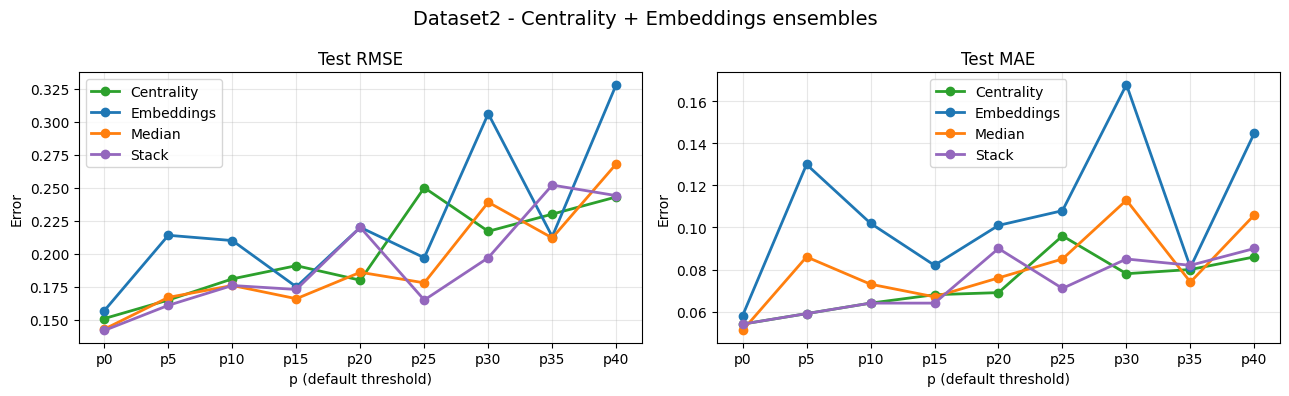

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/08_ensemble_centrality_embeddings/dataset2_ensemble_comparison.png


,p,best_test_rmse_method,best_test_rmse
0,p0,Stack,0.142
1,p5,Stack,0.161
2,p10,Median,0.176
3,p15,Median,0.166
4,p20,Centrality,0.180
5,p25,Stack,0.165
6,p30,Stack,0.197
7,p35,Median,0.212
8,p40,Centrality,0.243


In [9]:
plot_dataset_ensemble(metrics, 'dataset2', 'dataset2_ensemble_comparison.png')
display(winner_table(metrics, 'dataset2'))